# Workshop 9: Reinforcement Learning

Welcome! In this notebook we'll go from the basics covered in the slides to actually implementing RL algorithms and watching them learn.

**The RL Loop** (from the slides):
1. **Observe state** — the agent sees where it is
2. **Choose action** — using its policy
3. **Get reward & new state** — from the environment
4. **Update estimates** — improve Q(s, a) based on experience

**Key concepts:**
- **Policy**: a function giving the probability of which action to take in each state
- **V(s)**: state-value — how good is it to *be* in state s?
- **Q(s, a)**: action-value — how good is it to take action a in state s?
- RL in a nutshell: learn to approximate Q(s, a) from experience

**What we'll build:**
1. **Multi-Armed Bandit** — one state, multiple actions → learn Q(a) with simple averaging
2. **Q-Learning on FrozenLake** — add states → full Q(s, a) table updated with the Bellman equation
3. **Deep Q-Network (DQN)** — replace the table with a neural network → handle continuous state spaces

## Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

np.random.seed(42)

---
## Part 1 — Multi-Armed Bandit

### What is a bandit problem?

Imagine a row of $k$ slot machines ("one-armed bandits"). Each machine pays out a different average reward, but you don't know which is best. You have a limited number of pulls — how do you find the best machine quickly?

This is the **pure exploration vs exploitation** problem:
- **Exploit** — pull the machine you *think* is best right now
- **Explore** — try machines you haven't pulled much, in case a better one exists

There's only **one state** here, so we just need `Q[a]` (no state index).

In [8]:
class BanditEnv:
    """k-armed bandit. Each arm has a hidden true value drawn from N(0,1).
    Calling step(action) returns a noisy reward around that true value."""

    def __init__(self, k=10, seed=None):
        rng = np.random.default_rng(seed)
        self.k = k
        self.true_values = rng.standard_normal(k)   # hidden — agent can't see these!
        self.best_action = np.argmax(self.true_values)

    def step(self, action):
        """Returns a noisy reward for the chosen arm."""
        return np.random.randn() + self.true_values[action]


env = BanditEnv(k=10, seed=0)
print('True values (hidden from agent):', np.round(env.true_values, 2))
print('Best arm:', env.best_action)

True values (hidden from agent): [ 0.13 -0.13  0.64  0.1  -0.54  0.36  1.3   0.95 -0.7  -1.27]
Best arm: 6


### 1.1 Implementing epsilon-greedy

The **epsilon-greedy** strategy:
- With probability `epsilon` → pick a **random** arm (explore)
- Otherwise → pick the arm with the **highest Q estimate** (exploit)

We update Q estimates using **exponential averaging**:
$$Q_{t+1}(a) = Q_t(a) + \alpha \left[r_{t+1} - Q_t(a)\right]$$

**Your task:** fill in the two `TODO` sections below.

In [9]:
def run_bandit(env, n_steps=1000, epsilon=0.1, alpha=0.1):
    """
    Run epsilon-greedy on a BanditEnv for n_steps.
    Returns:
        rewards        - reward received at each step
        optimal_chosen - bool array: True when we picked the best arm
        Q              - final Q estimates
    """
    Q = np.zeros(env.k)
    rewards = np.zeros(n_steps)
    optimal_chosen = np.zeros(n_steps, dtype=bool)

    for t in range(n_steps):
        # --- TODO 1: Choose an action using epsilon-greedy ---
        # Hint: use np.random.random() < epsilon to decide whether to explore
        # Hint: use np.argmax(Q) to exploit
        action = None  # replace this
        if np.random.random() < epsilon:
            # exploration
            action = np.random.randint(0, 10)
        else: 
            # exploitation
            action = np.argmax(Q)

        # Get reward from environment
        reward = env.step(action)

        # --- TODO 2: Update Q[action] using exponential averaging ---
        # Q(a) = Q(a) + alpha * (reward - Q(a))
        Q[action] = Q[action] + alpha * (reward - Q[action])

        rewards[t] = reward
        optimal_chosen[t] = (action == env.best_action)

    return rewards, optimal_chosen, Q


# Quick sanity check (won't plot yet)
rewards, optimal, Q_final = run_bandit(env, n_steps=500, epsilon=0.1)
print('Mean reward over last 100 steps:', np.mean(rewards[-100:]).round(2))
print('% optimal action in last 100 steps:', np.mean(optimal[-100:]) * 100, '%')

Mean reward over last 100 steps: 1.1
% optimal action in last 100 steps: 84.0 %


### 1.2 Comparing different epsilon values

Let's run the same bandit 20 times (different random seeds) for each epsilon and average the results to get a fair comparison.

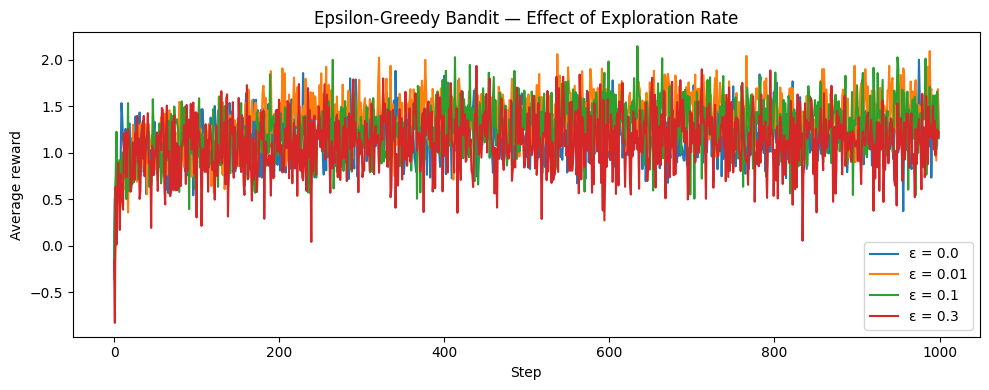

In [10]:
N_RUNS   = 20
N_STEPS  = 1000
EPSILONS = [0.0, 0.01, 0.1, 0.3]

results = {}  # epsilon -> average rewards over time

for eps in EPSILONS:
    all_rewards = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        e = BanditEnv(k=10, seed=run)
        r, _, _ = run_bandit(e, n_steps=N_STEPS, epsilon=eps, alpha=0.1)
        all_rewards[run] = r
    results[eps] = all_rewards.mean(axis=0)

plt.figure(figsize=(10, 4))
for eps, avg_rewards in results.items():
    plt.plot(avg_rewards, label=f'ε = {eps}')
plt.xlabel('Step')
plt.ylabel('Average reward')
plt.title('Epsilon-Greedy Bandit — Effect of Exploration Rate')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — Q-Learning on FrozenLake

### The environment

[FrozenLake-v1](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) is a 4×4 grid. The agent starts at `S` and must reach the goal `G` without falling through holes `H`.

```
S F F F
F H F H
F F F H
H F F G
```
- **States:** 16 grid positions (0–15)
- **Actions:** Left (0), Down (1), Right (2), Up (3)
- **Reward:** +1 for reaching G, 0 everywhere else
- **Slippery:** by default the ice is slippery, so you don't always move the direction you intended!

We'll use `is_slippery=False` first to keep things simpler.

In [11]:
env_fl = gym.make('FrozenLake-v1', is_slippery=False)

n_states  = env_fl.observation_space.n   # 16
n_actions = env_fl.action_space.n        # 4

print(f'States: {n_states},  Actions: {n_actions}')
print('Action meanings: 0=Left  1=Down  2=Right  3=Up')

States: 16,  Actions: 4
Action meanings: 0=Left  1=Down  2=Right  3=Up


### 2.1 Implementing Q-Learning

The Q-Learning update rule:
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[r_t + \gamma \max_{a} Q(s_{t+1}, a) - Q(s_t, a_t)\right]$$

Note the `max` — we update towards the **best possible next action**, regardless of what we actually do next. That's what makes it **off-policy**.

**Your task:** fill in the `TODO` sections.

In [12]:
def train_qlearning(env, n_episodes=5000, alpha=0.8, gamma=0.99,
                    epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.999):
    """
    Train a Q-table using Q-Learning with decaying epsilon-greedy exploration.
    Returns the learned Q-table and per-episode rewards.
    """
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    epsilon = epsilon_start
    episode_rewards = []

    for episode in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # --- TODO 1: Epsilon-greedy action selection ---
            # Explore: env.action_space.sample()  /  Exploit: np.argmax(Q[state])
            action = None  # replace this
            if np.random.random() < epsilon: 
                action = env.action_space.sample()
            else: 
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # --- TODO 2: Q-Learning update ---
            target = 0
            if done: 
                target = reward
            else: 
                target = reward + gamma * max(Q[next_state])
            Q[state, action] += alpha * (target - Q[state, action])


            total_reward += reward
            state = next_state

        # Decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    return Q, episode_rewards


Q_table, ep_rewards = train_qlearning(env_fl, n_episodes=5000)
print('Training complete!')
print(f'Win rate in last 500 episodes: {np.mean(ep_rewards[-500:]) * 100:.1f}%')

Training complete!
Win rate in last 500 episodes: 95.8%


### 2.2 Visualising the learned policy

Let's see what action the agent has learned to take in each cell.

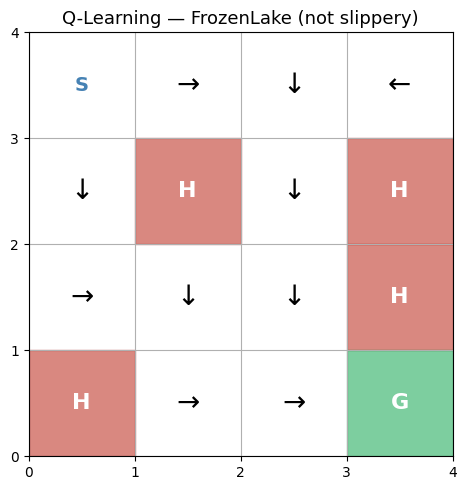

In [13]:
# This is just for visualization — you don't need to understand the code below
def plot_policy(Q, grid_size=4, title='Learned Policy'):
    """Display the greedy policy as arrows on the grid."""
    arrows = ['←', '↓', '→', '↑']
    holes  = {5, 7, 11, 12}  # FrozenLake-v1 default holes
    goal   = 15

    policy = np.argmax(Q, axis=1).reshape(grid_size, grid_size)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_xticks(range(grid_size + 1))
    ax.set_yticks(range(grid_size + 1))
    ax.grid(True)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)

    for row in range(grid_size):
        for col in range(grid_size):
            s = row * grid_size + col
            cx, cy = col + 0.5, (grid_size - 1 - row) + 0.5
            if s in holes:
                ax.add_patch(plt.Rectangle((col, grid_size - 1 - row), 1, 1,
                                           color='#c0392b', alpha=0.6))
                ax.text(cx, cy, 'H', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
            elif s == goal:
                ax.add_patch(plt.Rectangle((col, grid_size - 1 - row), 1, 1,
                                           color='#27ae60', alpha=0.6))
                ax.text(cx, cy, 'G', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
            elif s == 0:
                ax.text(cx, cy, 'S', ha='center', va='center', fontsize=14, color='steelblue', fontweight='bold')
            else:
                ax.text(cx, cy, arrows[policy[row, col]],
                        ha='center', va='center', fontsize=20)

    plt.tight_layout()
    plt.show()


plot_policy(Q_table, title='Q-Learning — FrozenLake (not slippery)')

### 2.2b State-value function V(s)

The slides introduced both V(s) and Q(s,a). Now that we have a trained Q-table, we can derive V(s) directly:

$$V(s) = \max_a Q(s, a)$$

This tells us how good each *position* on the grid is — independent of which action we take.

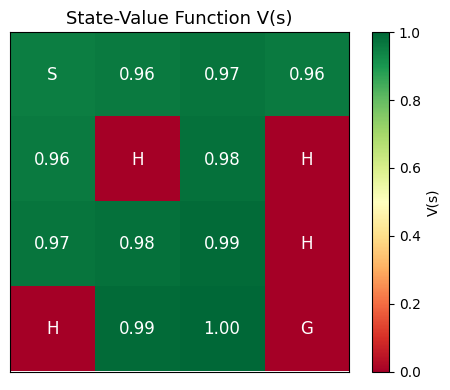

In [14]:
# again, only for visualiation
V = np.max(Q_table, axis=1).reshape(4, 4)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(V, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='V(s)')
ax.set_title('State-Value Function V(s)', fontsize=13)

holes = {5, 7, 11, 12}
for row in range(4):
    for col in range(4):
        s = row * 4 + col
        if s in holes:
            label = 'H'
        elif s == 15:
            label = 'G'
        elif s == 0:
            label = 'S'
        else:
            label = f'{V[row, col]:.2f}'
        brightness = V[row, col]
        color = 'black' if 0.25 < brightness < 0.85 else 'white'
        ax.text(col, row, label, ha='center', va='center', fontsize=12, color=color)

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

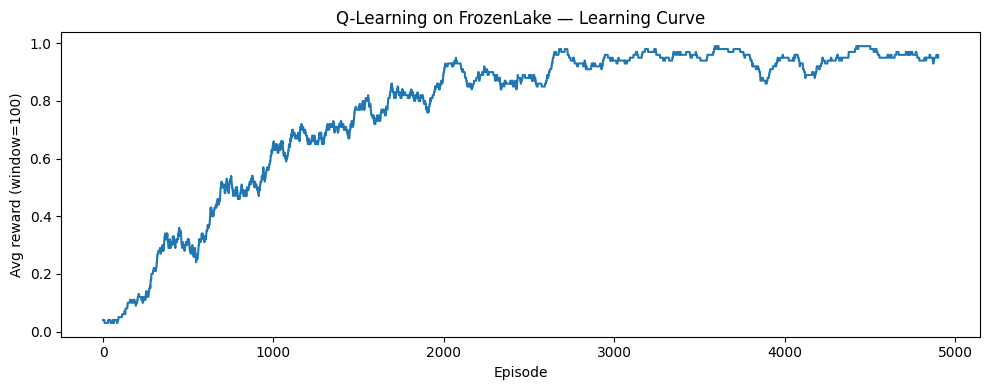

In [15]:
# Plot the learning curve — smoothed over 100-episode windows
window = 100
smoothed = np.convolve(ep_rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed)
plt.xlabel('Episode')
plt.ylabel(f'Avg reward (window={window})')
plt.title('Q-Learning on FrozenLake — Learning Curve')
plt.tight_layout()
plt.show()

### 2.3 Evaluate the trained policy

Now let's turn off exploration (epsilon = 0) and run 100 evaluation episodes to see how well the agent actually performs.

In [16]:
def evaluate(Q, env, n_eval=100):
    wins = 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        while not done:
            action = np.argmax(Q[state])          # always greedy
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        wins += reward  # reward=1 only at goal
    return wins / n_eval


win_rate = evaluate(Q_table, env_fl)
print(f'Win rate (greedy, no exploration): {win_rate * 100:.0f}%')

Win rate (greedy, no exploration): 100%


### 2.4 Slippery ice

Now try the harder version where actions are stochastic — the agent has 1/3 chance moving in the direction it chooses, and 2/3 it moves __perpendicularly__. You may need more episodes and a lower alpha.

Win rate on slippery lake: 77%


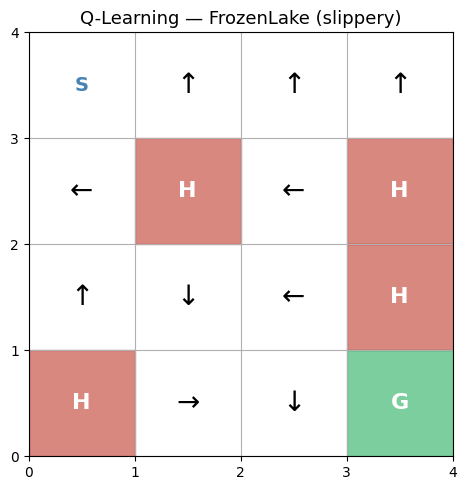

In [17]:
env_slip = gym.make('FrozenLake-v1', is_slippery=True)

Q_slip, rewards_slip = train_qlearning(env_slip, n_episodes=20000,
                                       alpha=0.1, gamma=0.99,
                                       epsilon_start=1.0,
                                       epsilon_end=0.05,
                                       epsilon_decay=0.9995)

wr = evaluate(Q_slip, env_slip)
print(f'Win rate on slippery lake: {wr * 100:.0f}%')
plot_policy(Q_slip, title='Q-Learning — FrozenLake (slippery)')

**Discussion questions:**
- Why does the agent sometimes point *away* from the goal in the slippery version?

---
## Part 3 — Deep Q-Network on CartPole

### Why do we need a network?

FrozenLake had 16 discrete states — a Q-table worked fine. But **CartPole** has a state of 4 continuous numbers (cart position, velocity, pole angle, angular velocity). A table would need infinitely many rows.

**The slide's key idea:** replace the Q-table with a neural network.
- **Input:** state vector
- **Output:** one Q-value per action

We train it with the exact same Bellman target as tabular Q-Learning:
$$\text{target} = r + \gamma \max_{a'} Q_{\text{net}}(s', a')$$

This becomes a standard supervised regression loss: `MSE(Q_net(s)[a], target)`.

Two tricks that make DQN stable in practice:
- **Replay buffer**: store past transitions and sample randomly — breaks temporal correlation
- **Target network**: a frozen copy of Q_net used to compute targets — prevents moving goalposts

> **Note:** requires PyTorch (`pip install torch`). The architecture below is the same as Workshop 8.

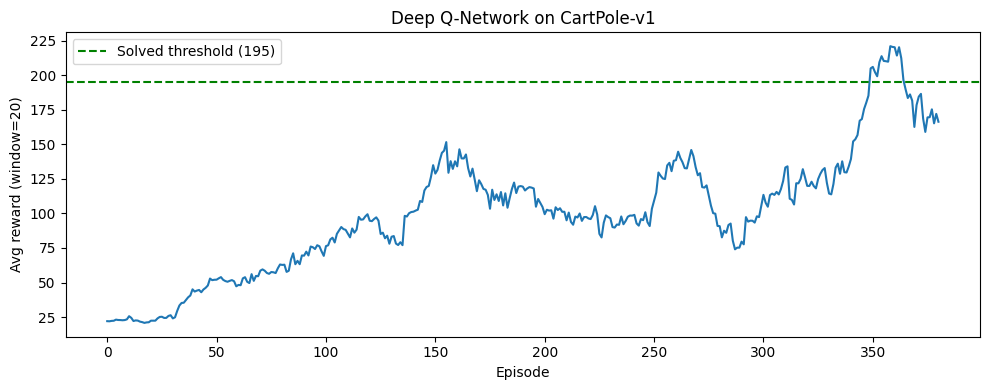

Mean reward in last 50 episodes: 187.7
CartPole is "solved" at a mean reward ≥ 195 over 100 consecutive episodes.


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# --- Q-Network: maps state vector → Q-value for each action ---
# This replaces the Q-table: instead of Q[state, action] we compute Q_net(state)[action]
class QNetwork(nn.Module):
    def __init__(self, n_obs, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        return self.net(x)

# --- Replay buffer: store past (s, a, r, s', done) transitions and sample randomly ---
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buf = deque(maxlen=capacity)
    def push(self, *transition):
        self.buf.append(transition)
    def sample(self, batch_size):
        return zip(*random.sample(self.buf, batch_size))
    def __len__(self):
        return len(self.buf)

def train_dqn(n_episodes=400, gamma=0.99, lr=1e-3,
              epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
              batch_size=64):
    env = gym.make('CartPole-v1')
    n_obs     = env.observation_space.shape[0]  # 4 continuous values — can't use a Q-table!
    n_actions = env.action_space.n              # 2: push left or push right

    q_net      = QNetwork(n_obs, n_actions)
    target_net = QNetwork(n_obs, n_actions)     # frozen copy for computing stable targets
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    buffer    = ReplayBuffer()
    epsilon   = epsilon_start
    episode_rewards = []

    for episode in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # --- TODO 1: Epsilon-greedy action selection ---
            # Explore:  action = env.action_space.sample()
            # Exploit:  use q_net to get Q-values, then pick argmax
            #           q_vals = q_net(torch.tensor(state, dtype=torch.float32))
            #           action = q_vals.argmax().item()
            # Wrap the exploit branch in: with torch.no_grad():
            action = None  # replace this
            if np.random.random() < epsilon: 
                # Explore
                action = env.action_space.sample()
            else: 
                with torch.no_grad(): 
                    q_vals = q_net(torch.tensor(state, dtype=torch.float32))
                    action = q_vals.argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state

            if len(buffer) >= batch_size:
                states, actions, rewards_b, next_states, dones = buffer.sample(batch_size)

                states      = torch.tensor(list(states),      dtype=torch.float32)
                actions     = torch.tensor(list(actions),     dtype=torch.long)
                rewards_b   = torch.tensor(list(rewards_b),   dtype=torch.float32)
                next_states = torch.tensor(list(next_states), dtype=torch.float32)
                dones       = torch.tensor(list(dones),       dtype=torch.float32)

                # Q-values for the actions actually taken
                current_q = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()

                # --- TODO 2: Compute the Bellman target ---
                # Same equation as Q-Learning: target = r + γ * max Q(s', a')
                # Use target_net (not q_net) to get Q-values for next_states
                # Set target = rewards_b when done (multiply by 1 - dones to zero out terminal states)
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1).values
                    target_q = rewards_b + gamma * (1 - dones) * next_q_values


                loss = nn.MSELoss()(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    env.close()
    return episode_rewards

ep_rewards_dqn = train_dqn(n_episodes=400)

window = 20
smoothed_dqn = np.convolve(ep_rewards_dqn, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_dqn)
plt.axhline(y=195, color='green', linestyle='--', label='Solved threshold (195)')
plt.xlabel('Episode')
plt.ylabel(f'Avg reward (window={window})')
plt.title('Deep Q-Network on CartPole-v1')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean reward in last 50 episodes: {np.mean(ep_rewards_dqn[-50:]):.1f}')
print('CartPole is "solved" at a mean reward ≥ 195 over 100 consecutive episodes.')

---
## Wrap-up

Today we followed the full arc of the slides — from the simplest RL setting to a modern deep RL algorithm:

| Algorithm | Setting | Key update |
|-----------|---------|------------|
| Epsilon-Greedy Bandit | One state, Q(a) | `Q += α(r - Q)` |
| Q-Learning | Q-table, Q(s,a) | `Q += α(r + γ·max Q' - Q)` |
| Deep Q-Network | Neural net as Q | same Bellman target, backprop instead of table update |

**Where to go from here:**
- **Policy Gradient methods:** directly learn the policy as a neural network (no Q-values needed)
- **Actor-Critic:** combine both — used in RLHF training for LLMs like ChatGPT
- Try more Gymnasium environments: `MountainCar-v0`, `LunarLander-v3`, `Atari` games